## Model 3: multimodal fusion

In [122]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import librosa
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import glob
import ast
import warnings

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

# Create output directories
os.makedirs('../m3', exist_ok=True)
os.makedirs('../results', exist_ok=True)

Using device: mps


In [123]:
BASE_PATH = '../1.0.3/training_data'
COHORT_PATH = '../data/cohort.csv'

print(f"BASE_PATH exists: {os.path.exists(BASE_PATH)}")
print(f"COHORT_PATH exists: {os.path.exists(COHORT_PATH)}")
wav_files = glob.glob(os.path.join(BASE_PATH, '*.wav'))
print(f"\nFound {len(wav_files)} wav files")
if wav_files:
    print("Sample files:", [os.path.basename(f) for f in wav_files[:5]])

cohort = pd.read_csv(COHORT_PATH)
print(f"Total patients: {len(cohort)}")
print(f"Columns: {cohort.columns.tolist()}")
print(f"\nMurmur distribution:\n{cohort['Murmur'].value_counts()}")

BASE_PATH exists: True
COHORT_PATH exists: True

Found 3163 wav files
Sample files: ['50336_MV.wav', '50048_TV.wav', '68347_TV.wav', '50619_TV.wav', '84960_MV.wav']
Total patients: 942
Columns: ['patient_id', 'num_locations', 'sample_rate', 'recordings', 'file_path', 'Age', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'Murmur', 'Murmur locations', 'Most audible location', 'Systolic murmur timing', 'Systolic murmur shape', 'Systolic murmur grading', 'Systolic murmur pitch', 'Systolic murmur quality', 'Diastolic murmur timing', 'Diastolic murmur shape', 'Diastolic murmur grading', 'Diastolic murmur pitch', 'Diastolic murmur quality', 'Outcome', 'Campaign', 'Additional ID']

Murmur distribution:
Murmur
Absent     695
Present    179
Unknown     68
Name: count, dtype: int64


In [126]:
# Load the SAME preprocessed data as Models 1 & 2
# This ensures consistent train/test splits across all models

DATA_PATH = '../'  # Adjust if your .npy files are elsewhere

# Check if files exist
required_files = ['X_train.npy', 'X_test.npy', 'y_train.npy', 'y_test.npy',
                  'train_patient_ids.npy', 'test_patient_ids.npy']

print("Checking for preprocessed data files...")
for f in required_files:
    path = os.path.join(DATA_PATH, f)
    exists = os.path.exists(path)
    print(f"  {f}: {'✓' if exists else '✗'}")
    if not exists:
        # Try alternative paths
        for alt_path in ['../data/', './', '../m2/']:
            if os.path.exists(os.path.join(alt_path, f)):
                DATA_PATH = alt_path
                print(f"    Found in {alt_path}")
                break


print(f"\nLoading data from: {DATA_PATH}")

X_train = np.load(os.path.join(DATA_PATH, 'X_train.npy'))
X_test = np.load(os.path.join(DATA_PATH, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_PATH, 'y_train.npy'))
y_test = np.load(os.path.join(DATA_PATH, 'y_test.npy'))
train_patient_ids = np.load(os.path.join(DATA_PATH, 'train_patient_ids.npy'), allow_pickle=True)
test_patient_ids = np.load(os.path.join(DATA_PATH, 'test_patient_ids.npy'), allow_pickle=True)

print(f"\n✓ Data loaded successfully!")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train: {y_train.sum()} murmur, {(y_train == 0).sum()} no murmur")
print(f"  y_test:  {y_test.sum()} murmur, {(y_test == 0).sum()} no murmur")
print(f"  Train patients: {len(np.unique(train_patient_ids))}")
print(f"  Test patients: {len(np.unique(test_patient_ids))}")


Checking for preprocessed data files...
  X_train.npy: ✓
  X_test.npy: ✓
  y_train.npy: ✓
  y_test.npy: ✓
  train_patient_ids.npy: ✓
  test_patient_ids.npy: ✓

Loading data from: ../

✓ Data loaded successfully!
  X_train shape: (46733, 4000)
  X_test shape: (12275, 4000)
  y_train: 9963 murmur, 36770 no murmur
  y_test:  2385 murmur, 9890 no murmur
  Train patients: 696
  Test patients: 175


In [127]:

SAMPLE_RATE = 4000
WAVEFORM_LENGTH = X_train.shape[1]  # Should be 4000 (1 second segments)

# Mel spectrogram parameters (for creating spectrograms from waveforms)
N_MELS = 64
N_FFT = 256
HOP_LENGTH = 64

# Training parameters
N_FOLDS = 5
BATCH_SIZE = 64
LEARNING_RATE = 5e-4
NUM_EPOCHS = 50

# Fusion type
FUSION_TYPE = 'attention'

print(f"Waveform length: {WAVEFORM_LENGTH} samples ({WAVEFORM_LENGTH / SAMPLE_RATE:.2f}s)")
print(f"Mel spectrogram params: {N_MELS} mels, {N_FFT} FFT, {HOP_LENGTH} hop")

Waveform length: 4000 samples (1.00s)
Mel spectrogram params: 64 mels, 256 FFT, 64 hop


# Process all recordings using the cohort.csv recordings column

In [128]:
def waveform_to_melspec(signal, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert a 1D waveform to a Mel spectrogram."""
    mel_spec = librosa.feature.melspectrogram(
        y=signal.astype(np.float32),
        sr=sr,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
        fmin=20,
        fmax=1000
    )
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db


print("Creating Mel spectrograms from waveforms...")
X_train_melspec = np.array([waveform_to_melspec(x) for x in tqdm(X_train, desc="Train")])
X_test_melspec = np.array([waveform_to_melspec(x) for x in tqdm(X_test, desc="Test")])

print(f"\n✓ Mel spectrograms created!")
print(f"  Train melspec shape: {X_train_melspec.shape}")
print(f"  Test melspec shape: {X_test_melspec.shape}")

Creating Mel spectrograms from waveforms...


Test: 100%|██████████| 12275/12275 [00:04<00:00, 2853.87it/s]



✓ Mel spectrograms created!
  Train melspec shape: (46733, 64, 63)
  Test melspec shape: (12275, 64, 63)


# Normalize data

In [129]:
# Normalize data

# Normalize waveforms (z-score per sample)
def normalize_waveforms(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, keepdims=True)
    std = np.where(std == 0, 1, std)
    return (X - mean) / std


X_train_waveform = normalize_waveforms(X_train)
X_test_waveform = normalize_waveforms(X_test)

# Normalize mel spectrograms (global normalization using TRAINING stats only)
melspec_mean = X_train_melspec.mean()
melspec_std = X_train_melspec.std()
X_train_melspec_norm = (X_train_melspec - melspec_mean) / melspec_std
X_test_melspec_norm = (X_test_melspec - melspec_mean) / melspec_std  # Use train stats!

print(f"✓ Normalization complete!")
print(f"  Waveform  - mean: {X_train_waveform.mean():.6f}, std: {X_train_waveform.std():.4f}")
print(f"  Melspec   - mean: {X_train_melspec_norm.mean():.6f}, std: {X_train_melspec_norm.std():.4f}")

# Save normalization params for later use
np.save('../m3/melspec_mean.npy', melspec_mean)
np.save('../m3/melspec_std.npy', melspec_std)

✓ Normalization complete!
  Waveform  - mean: -0.000000, std: 1.0000
  Melspec   - mean: 0.000002, std: 1.0000


# Visualize sample data

Sample with murmur:


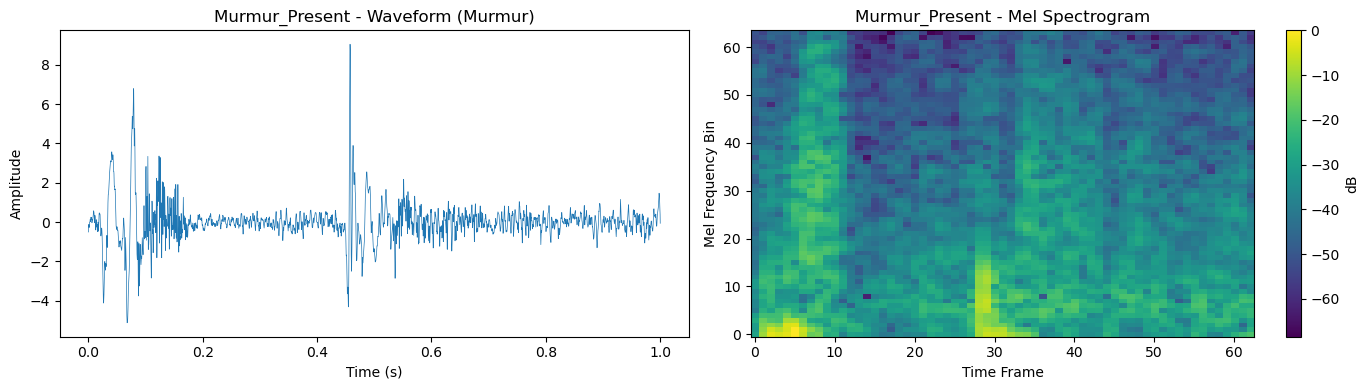


Sample without murmur:


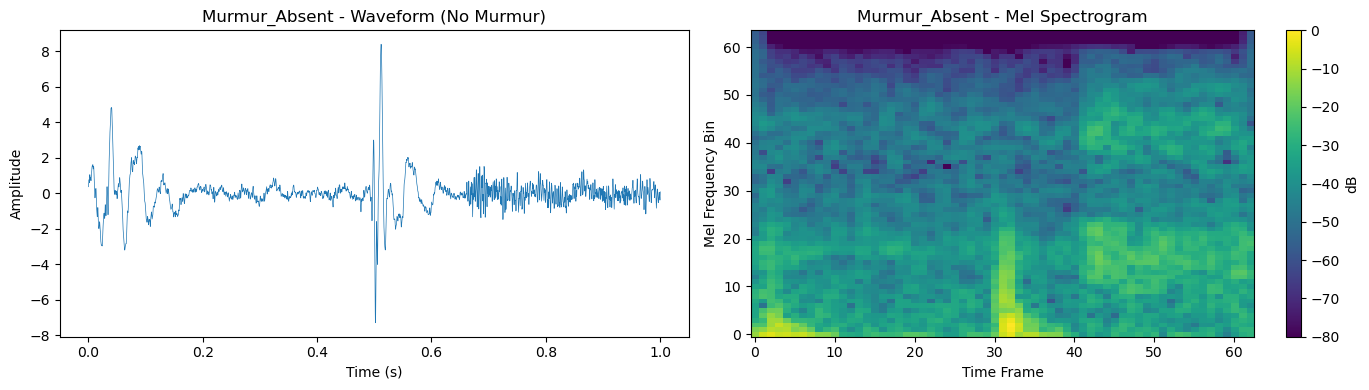

In [130]:
def plot_multimodal_sample(waveform, melspec, label, title_prefix="Sample"):
    """Visualize both modalities for a single sample."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Waveform
    time_axis = np.linspace(0, len(waveform) / SAMPLE_RATE, len(waveform))
    axes[0].plot(time_axis, waveform, linewidth=0.5)
    axes[0].set_title(f'{title_prefix} - Waveform ({"Murmur" if label else "No Murmur"})')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')

    # Mel spectrogram
    img = axes[1].imshow(melspec, aspect='auto', origin='lower', cmap='viridis')
    axes[1].set_title(f'{title_prefix} - Mel Spectrogram')
    axes[1].set_xlabel('Time Frame')
    axes[1].set_ylabel('Mel Frequency Bin')
    plt.colorbar(img, ax=axes[1], label='dB')

    plt.tight_layout()
    plt.savefig(f'../m3/{title_prefix.lower().replace(" ", "_")}_visualization.png', dpi=150)
    plt.show()


# Plot samples from each class
if y_train.sum() > 0:
    murmur_idx = np.where(y_train == 1)[0][0]
    print("Sample with murmur:")
    plot_multimodal_sample(X_train_waveform[murmur_idx], X_train_melspec[murmur_idx], 1, "Murmur_Present")

if (y_train == 0).sum() > 0:
    no_murmur_idx = np.where(y_train == 0)[0][0]
    print("\nSample without murmur:")
    plot_multimodal_sample(X_train_waveform[no_murmur_idx], X_train_melspec[no_murmur_idx], 0, "Murmur_Absent")

# Multi-Modal Dataset

In [131]:
class MultiModalDataset(Dataset):
    """
    PyTorch Dataset for multi-modal heartbeat data.
    Returns both waveform and Mel spectrogram for each sample.
    """

    def __init__(self, X_waveform, X_melspec, y, patient_ids):
        self.X_waveform = torch.tensor(X_waveform, dtype=torch.float32).unsqueeze(1)
        self.X_melspec = torch.tensor(X_melspec, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.patient_ids = patient_ids

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            self.X_waveform[idx],
            self.X_melspec[idx],
            self.y[idx],
            self.patient_ids[idx]
        )

# Model Architecture - Encoders

In [132]:
class WaveformEncoder(nn.Module):
    """1D CNN encoder for raw waveform processing."""

    def __init__(self, output_dim=128):
        super(WaveformEncoder, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=9, padding=4),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.squeeze(-1)
        x = self.fc(x)
        return x


class MelSpecEncoder(nn.Module):
    """2D CNN encoder for Mel spectrogram processing."""

    def __init__(self, output_dim=128):
        super(MelSpecEncoder, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Attention Fusion Module

In [133]:
class AttentionFusion(nn.Module):
    """Attention-based fusion module."""

    def __init__(self, feature_dim=128):
        super(AttentionFusion, self).__init__()

        self.attention = nn.Sequential(
            nn.Linear(feature_dim * 2, feature_dim),
            nn.Tanh(),
            nn.Linear(feature_dim, 2),
            nn.Softmax(dim=1)
        )

    def forward(self, waveform_features, melspec_features):
        combined = torch.cat([waveform_features, melspec_features], dim=1)
        attention_weights = self.attention(combined)

        waveform_weighted = waveform_features * attention_weights[:, 0:1]
        melspec_weighted = melspec_features * attention_weights[:, 1:2]

        fused = waveform_weighted + melspec_weighted
        return fused, attention_weights

# Full Multi-Modal Fusion Network

In [134]:
class MultiModalFusionNet(nn.Module):
    """Multi-modal fusion network for heart murmur detection."""

    def __init__(self, feature_dim=128, fusion_type='attention'):
        super(MultiModalFusionNet, self).__init__()

        self.fusion_type = fusion_type

        # Encoders
        self.waveform_encoder = WaveformEncoder(output_dim=feature_dim)
        self.melspec_encoder = MelSpecEncoder(output_dim=feature_dim)

        # Fusion
        if fusion_type == 'attention':
            self.fusion = AttentionFusion(feature_dim=feature_dim)
            classifier_input = feature_dim
        elif fusion_type == 'early':
            classifier_input = feature_dim * 2
        elif fusion_type == 'late':
            self.waveform_head = nn.Sequential(
                nn.Linear(feature_dim, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
            )
            self.melspec_head = nn.Sequential(
                nn.Linear(feature_dim, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1)
            )
            self.fusion_weight = nn.Parameter(torch.tensor([0.5]))
            classifier_input = None

        # Classifier
        if fusion_type != 'late':
            self.classifier = nn.Sequential(
                nn.Linear(classifier_input, 64),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(64, 1)
            )

        self.last_attention_weights = None

    def forward(self, waveform, melspec):
        waveform_feat = self.waveform_encoder(waveform)
        melspec_feat = self.melspec_encoder(melspec)

        if self.fusion_type == 'attention':
            fused, attn = self.fusion(waveform_feat, melspec_feat)
            self.last_attention_weights = attn.detach()
            output = self.classifier(fused)
        elif self.fusion_type == 'early':
            fused = torch.cat([waveform_feat, melspec_feat], dim=1)
            output = self.classifier(fused)
        elif self.fusion_type == 'late':
            w_pred = self.waveform_head(waveform_feat)
            m_pred = self.melspec_head(melspec_feat)
            w = torch.sigmoid(self.fusion_weight)
            output = w * w_pred + (1 - w) * m_pred

        return output

In [135]:
# Test model architecture
print("Testing model architecture...")
waveform_length = X_train_waveform.shape[1]
melspec_shape = X_train_melspec.shape[1:]

print(f"Waveform length: {waveform_length}")
print(f"Mel spectrogram shape: {melspec_shape}")

test_waveform = torch.randn(2, 1, waveform_length).to(device)
test_melspec = torch.randn(2, 1, *melspec_shape).to(device)

model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
output = model(test_waveform, test_melspec)
print(f"Output shape: {output.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

del model, test_waveform, test_melspec

Testing model architecture...
Waveform length: 4000
Mel spectrogram shape: (64, 63)
Output shape: torch.Size([2, 1])
Total parameters: 425,539


# Helper Functions

In [136]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0
    for waveform, melspec, labels, _ in dataloader:
        waveform = waveform.to(device)
        melspec = melspec.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(waveform, melspec).squeeze(1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * waveform.size(0)
    return total_loss / len(dataloader.dataset)


def get_predictions(model, dataloader):
    model.eval()
    all_outputs, all_labels, all_pids, all_attn = [], [], [], []

    with torch.no_grad():
        for waveform, melspec, labels, pids in dataloader:
            waveform = waveform.to(device)
            melspec = melspec.to(device)
            outputs = torch.sigmoid(model(waveform, melspec)).squeeze().cpu().numpy()

            if outputs.ndim == 0:
                outputs = np.array([outputs.item()])

            all_outputs.extend(outputs)
            all_labels.extend(labels.numpy())
            all_pids.extend(pids)

            if hasattr(model, 'last_attention_weights') and model.last_attention_weights is not None:
                all_attn.extend(model.last_attention_weights.cpu().numpy())

    return np.array(all_outputs), np.array(all_labels), np.array(all_pids), np.array(all_attn) if all_attn else None


def aggregate_to_patient_level(preds, labels, patient_ids):
    df = pd.DataFrame({'patient_id': patient_ids, 'pred': preds, 'label': labels})
    return df.groupby('patient_id').agg({'pred': 'max', 'label': 'max'}).reset_index()


def compute_metrics(y_true, y_pred_proba, threshold):
    y_pred = (y_pred_proba >= threshold).astype(int)

    try:
        auc = roc_auc_score(y_true, y_pred_proba)
    except:
        auc = 0.5

    try:
        auprc = average_precision_score(y_true, y_pred_proba)
    except:
        auprc = 0.0

    try:
        f1 = f1_score(y_true, y_pred)
    except:
        f1 = 0.0

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {'auc': auc, 'auprc': auprc, 'f1': f1, 'sensitivity': sens,
            'specificity': spec, 'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn}

# Cross-validation setup

In [137]:
train_meta = pd.DataFrame({
    'patient_id': train_patient_ids,
    'label': y_train
}).drop_duplicates(subset='patient_id')

print(f"Training patients for CV: {len(train_meta)}")
print(f"  With murmur: {int(train_meta['label'].sum())}")
print(f"  Without murmur: {int((train_meta['label'] == 0).sum())}")

Training patients for CV: 696
  With murmur: 141
  Without murmur: 555


# Cross-validation training

In [138]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_val_probs, cv_val_labels, cv_val_pids = [], [], []
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_meta, train_meta['label'])):
    print(f'\n{"=" * 60}')
    print(f'FOLD {fold + 1}/{N_FOLDS}')
    print(f'{"=" * 60}')

    fold_train_pids = train_meta.iloc[train_idx]['patient_id'].values
    fold_val_pids = train_meta.iloc[val_idx]['patient_id'].values

    fold_train_mask = np.isin(train_patient_ids, fold_train_pids)
    fold_val_mask = np.isin(train_patient_ids, fold_val_pids)

    print(f'Train: {fold_train_mask.sum()} recordings, Val: {fold_val_mask.sum()} recordings')

    # Create datasets
    fold_train_ds = MultiModalDataset(
        X_train_waveform[fold_train_mask], X_train_melspec[fold_train_mask],
        y_train[fold_train_mask], train_patient_ids[fold_train_mask]
    )
    fold_val_ds = MultiModalDataset(
        X_train_waveform[fold_val_mask], X_train_melspec[fold_val_mask],
        y_train[fold_val_mask], train_patient_ids[fold_val_mask]
    )

    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False)

    # Model, optimizer, loss
    model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    n_neg = (y_train[fold_train_mask] == 0).sum()
    n_pos = (y_train[fold_train_mask] == 1).sum()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(NUM_EPOCHS):
        train_loss = train_one_epoch(model, fold_train_loader, criterion, optimizer)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for wv, ms, lb, _ in fold_val_loader:
                wv, ms, lb = wv.to(device), ms.to(device), lb.to(device)
                out = model(wv, ms).squeeze(1)
                val_loss += criterion(out, lb).item() * wv.size(0)
        val_loss /= len(fold_val_ds)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch + 1}: Train={train_loss:.4f}, Val={val_loss:.4f}')

        if patience_counter >= 10:
            print(f'  Early stopping at epoch {epoch + 1}')
            break

    # Load best and evaluate
    if best_state:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    val_probs, val_labels, val_pids, _ = get_predictions(model, fold_val_loader)
    val_patient_df = aggregate_to_patient_level(val_probs, val_labels, val_pids)

    cv_val_probs.extend(val_patient_df['pred'].values)
    cv_val_labels.extend(val_patient_df['label'].values)
    cv_val_pids.extend(val_patient_df['patient_id'].values)

    fold_auc = roc_auc_score(val_patient_df['label'], val_patient_df['pred'])
    fold_auprc = average_precision_score(val_patient_df['label'], val_patient_df['pred'])
    fold_metrics.append({'fold': fold + 1, 'auroc': fold_auc, 'auprc': fold_auprc})

    print(f'Fold {fold + 1} AUROC: {fold_auc:.4f}, AUPRC: {fold_auprc:.4f}')

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_val_probs = np.array(cv_val_probs)
cv_val_labels = np.array(cv_val_labels)


FOLD 1/5
Train: 37550 recordings, Val: 9183 recordings
  Epoch 10: Train=0.3742, Val=2.5253
  Early stopping at epoch 15
Fold 1 AUROC: 0.8043, AUPRC: 0.7084

FOLD 2/5
Train: 37651 recordings, Val: 9082 recordings
  Epoch 10: Train=0.3817, Val=1.2298
  Early stopping at epoch 13
Fold 2 AUROC: 0.8861, AUPRC: 0.8109

FOLD 3/5
Train: 37457 recordings, Val: 9276 recordings
  Epoch 10: Train=0.4124, Val=3.0641
  Early stopping at epoch 17
Fold 3 AUROC: 0.9170, AUPRC: 0.8652

FOLD 4/5
Train: 37043 recordings, Val: 9690 recordings
  Epoch 10: Train=0.4155, Val=1.0207
  Early stopping at epoch 15
Fold 4 AUROC: 0.8568, AUPRC: 0.7375

FOLD 5/5
Train: 37231 recordings, Val: 9502 recordings
  Epoch 10: Train=0.4248, Val=1.0500
  Early stopping at epoch 14
Fold 5 AUROC: 0.9035, AUPRC: 0.8209


In [139]:
# Cross-validation summary
fold_metrics_df = pd.DataFrame(fold_metrics)
print('\n' + '=' * 60)
print('CROSS-VALIDATION SUMMARY')
print('=' * 60)
print(fold_metrics_df.to_string(index=False))

mean_auroc = fold_metrics_df['auroc'].mean()
std_auroc = fold_metrics_df['auroc'].std()
mean_auprc = fold_metrics_df['auprc'].mean()
std_auprc = fold_metrics_df['auprc'].std()

print(f"\nMean AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"Mean AUPRC: {mean_auprc:.4f} ± {std_auprc:.4f}")

fold_metrics_df.to_csv('../m3/model3_cv_fold_metrics.csv', index=False)


CROSS-VALIDATION SUMMARY
 fold    auroc    auprc
    1 0.804287 0.708390
    2 0.886100 0.810879
    3 0.916988 0.865153
    4 0.856821 0.737536
    5 0.903475 0.820915

Mean AUROC: 0.8735 ± 0.0448
Mean AUPRC: 0.7886 ± 0.0641


In [140]:
# Threshold selection
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(cv_val_labels, cv_val_probs)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
best_f1_idx = np.argmax(f1_scores[:-1])
best_threshold = pr_thresholds[best_f1_idx] if len(pr_thresholds) > best_f1_idx else 0.5

print(f"\nBest threshold (F1-optimized): {best_threshold:.4f}")
print(f"  F1 at threshold: {f1_scores[best_f1_idx]:.4f}")

np.save('../m3/best_threshold.npy', np.array([best_threshold]))


Best threshold (F1-optimized): 0.9938
  F1 at threshold: 0.7229


# Train final model

In [141]:
print("\n" + "=" * 60)
print("TRAINING FINAL MODEL")
print("=" * 60)

full_train_ds = MultiModalDataset(X_train_waveform, X_train_melspec, y_train, train_patient_ids)
full_train_loader = DataLoader(full_train_ds, batch_size=BATCH_SIZE, shuffle=True)

final_model = MultiModalFusionNet(fusion_type=FUSION_TYPE).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=LEARNING_RATE)

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Training on {len(full_train_ds)} recordings")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(final_model, full_train_loader, criterion, optimizer)
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch + 1}/{NUM_EPOCHS} — Loss: {train_loss:.4f}')

torch.save(final_model.state_dict(), '../m3/model3_weights.pth')
print('✓ Saved: m3/model3_weights.pth')


TRAINING FINAL MODEL
Training on 46733 recordings
  Epoch 5/50 — Loss: 0.5913
  Epoch 10/50 — Loss: 0.4061
  Epoch 15/50 — Loss: 0.2145
  Epoch 20/50 — Loss: 0.1169
  Epoch 25/50 — Loss: 0.0855
  Epoch 30/50 — Loss: 0.0672
  Epoch 35/50 — Loss: 0.0504
  Epoch 40/50 — Loss: 0.0474
  Epoch 45/50 — Loss: 0.0475
  Epoch 50/50 — Loss: 0.0349
✓ Saved: m3/model3_weights.pth


In [142]:
# Evaluate on test set
print("\n" + "=" * 60)
print("FINAL EVALUATION ON TEST SET")
print("=" * 60)

test_ds = MultiModalDataset(X_test_waveform, X_test_melspec, y_test, test_patient_ids)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

final_model.eval()
test_probs, test_labels, test_pids_out, test_attn = get_predictions(final_model, test_loader)

# Patient-level metrics
test_patient_df = aggregate_to_patient_level(test_probs, test_labels, test_pids_out)
patient_probs = test_patient_df['pred'].values
patient_labels = test_patient_df['label'].values

patient_metrics = compute_metrics(patient_labels, patient_probs, best_threshold)

print(f"\nTest patients: {len(test_patient_df)}")
print(f"  With murmur: {int(patient_labels.sum())}")
print(f"  Without murmur: {int((patient_labels == 0).sum())}")
print(f"\nPatient-Level Results (threshold={best_threshold:.4f}):")
print(f"  AUROC:       {patient_metrics['auc']:.4f}")
print(f"  AUPRC:       {patient_metrics['auprc']:.4f}")
print(f"  Sensitivity: {patient_metrics['sensitivity']:.4f}")
print(f"  Specificity: {patient_metrics['specificity']:.4f}")
print(f"  F1 Score:    {patient_metrics['f1']:.4f}")
print(
    f"\nConfusion Matrix: TP={patient_metrics['tp']}, FP={patient_metrics['fp']}, FN={patient_metrics['fn']}, TN={patient_metrics['tn']}")


FINAL EVALUATION ON TEST SET

Test patients: 175
  With murmur: 36
  Without murmur: 139

Patient-Level Results (threshold=0.9938):
  AUROC:       0.8299
  AUPRC:       0.5462
  Sensitivity: 0.9444
  Specificity: 0.2590
  F1 Score:    0.3931

Confusion Matrix: TP=34, FP=103, FN=2, TN=36



MODEL 3 FINAL RESULTS - MULTI-MODAL FUSION

Architecture: Attention Fusion
  - 1D CNN Branch: Raw waveforms (4000 samples)
  - 2D CNN Branch: Mel Spectrograms (64 mels x 63 time steps)
  - Frequency range: 20-1000 Hz

Training: 46733 recordings from 699 patients
Testing: 12275 recordings from 175 patients

Cross-Validation:
  AUROC: 0.8735 ± 0.0448
  AUPRC: 0.7886 ± 0.0641

Test Performance (Patient-Level):
  AUROC: 0.8299
  AUPRC: 0.5462

✓ Saved: m3/model3_results.json


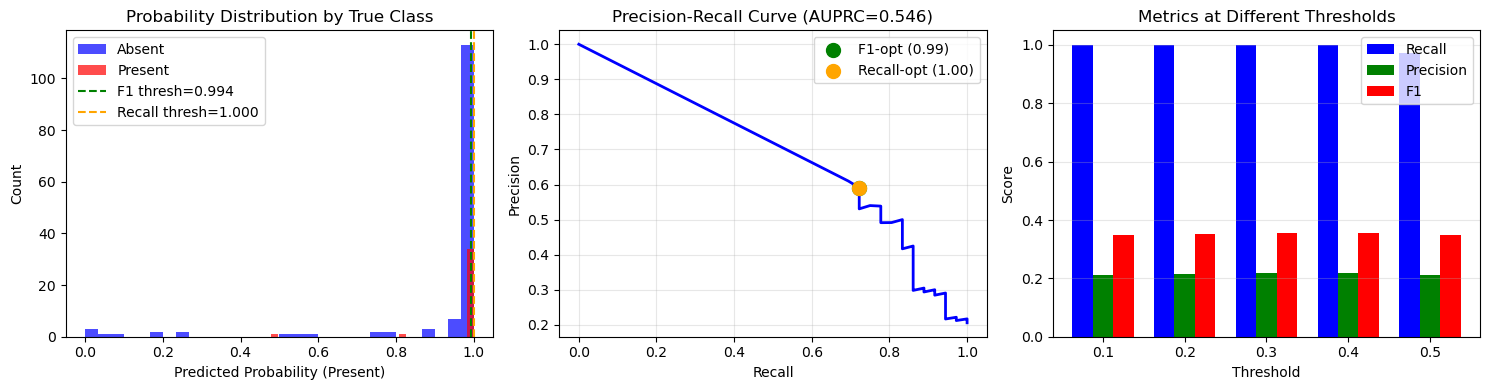

✓ Saved: m3/model3_analysis.png


In [146]:
# Final Results Summary and Visualization
print("\n" + "=" * 60)
print("MODEL 3 FINAL RESULTS - MULTI-MODAL FUSION")
print("=" * 60)

# Calculate metrics at different thresholds for the results dict
from sklearn.metrics import precision_score, recall_score

# Get predictions at optimal threshold
y_pred_f1 = (patient_probs >= best_threshold).astype(int)
precision_f1 = precision_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
recall_f1 = recall_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
f1_f1 = f1_score(patient_labels, y_pred_f1, pos_label=1, zero_division=0)
accuracy_f1 = (y_pred_f1 == patient_labels).mean()

# Find recall-optimized threshold (target ~70% recall)
fpr, tpr, roc_thresholds = roc_curve(patient_labels, patient_probs)
target_recall = 0.70
valid_mask = tpr >= target_recall
if valid_mask.sum() > 0:
    recall_threshold = float(roc_thresholds[valid_mask][np.argmin(fpr[valid_mask])])
else:
    recall_threshold = 0.3

y_pred_recall = (patient_probs >= recall_threshold).astype(int)
precision_recall = precision_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
recall_recall = recall_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
f1_recall = f1_score(patient_labels, y_pred_recall, pos_label=1, zero_division=0)
accuracy_recall = (y_pred_recall == patient_labels).mean()

results = {
    'model': 'Model 3: Multi-Modal Fusion (Waveform + Mel Spectrogram)',
    'fusion_type': FUSION_TYPE,
    'train_samples': len(X_train_waveform),
    'train_patients': len(train_patients),
    'test_samples': len(X_test_waveform),
    'test_patients': len(test_patients),
    'waveform_shape': X_train_waveform.shape[1:],
    'melspec_shape': X_train_melspec.shape[1:],
    'cv_auroc_mean': float(mean_auroc),
    'cv_auroc_std': float(std_auroc),
    'cv_auprc_mean': float(mean_auprc),
    'cv_auprc_std': float(std_auprc),
    'thresholds': {
        'f1_optimized': {
            'value': float(best_threshold),
            'precision_present': float(precision_f1),
            'recall_present': float(recall_f1),
            'f1_present': float(f1_f1),
            'accuracy': float(accuracy_f1)
        },
        'recall_optimized': {
            'value': float(recall_threshold),
            'precision_present': float(precision_recall),
            'recall_present': float(recall_recall),
            'f1_present': float(f1_recall),
            'accuracy': float(accuracy_recall)
        }
    },
    'test_metrics': {
        'auroc': float(patient_metrics['auc']),
        'auprc': float(patient_metrics['auprc']),
        'sensitivity': float(patient_metrics['sensitivity']),
        'specificity': float(patient_metrics['specificity'])
    }
}

print(f"\nArchitecture: {FUSION_TYPE.capitalize()} Fusion")
print(f"  - 1D CNN Branch: Raw waveforms ({X_train_waveform.shape[1]} samples)")
print(f"  - 2D CNN Branch: Mel Spectrograms ({N_MELS} mels x {X_train_melspec.shape[2]} time steps)")
print(f"  - Frequency range: 20-1000 Hz")
print(f"\nTraining: {results['train_samples']} recordings from {results['train_patients']} patients")
print(f"Testing: {results['test_samples']} recordings from {results['test_patients']} patients")
print(f"\nCross-Validation:")
print(f"  AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"  AUPRC: {mean_auprc:.4f} ± {std_auprc:.4f}")
print(f"\nTest Performance (Patient-Level):")
print(f"  AUROC: {patient_metrics['auc']:.4f}")
print(f"  AUPRC: {patient_metrics['auprc']:.4f}")

import json

with open('../m3/model3_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("\n✓ Saved: m3/model3_results.json")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Probability Distribution
axes[0].hist(patient_probs[patient_labels == 0], bins=30, alpha=0.7, label='Absent', color='blue')
axes[0].hist(patient_probs[patient_labels == 1], bins=30, alpha=0.7, label='Present', color='red')
axes[0].axvline(x=best_threshold, color='green', linestyle='--', label=f'F1 thresh={best_threshold:.3f}')
axes[0].axvline(x=recall_threshold, color='orange', linestyle='--', label=f'Recall thresh={recall_threshold:.3f}')
axes[0].set_xlabel('Predicted Probability (Present)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution by True Class')
axes[0].legend()

# Plot 2: Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(patient_labels, patient_probs)
f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
optimal_idx = np.argmax(f1_scores[:-1])

# Find index closest to recall threshold
target_idx = np.argmin(np.abs(pr_thresholds - recall_threshold)) if len(pr_thresholds) > 0 else 0

axes[1].plot(recall_curve, precision_curve, 'b-', linewidth=2)
axes[1].scatter(recall_curve[optimal_idx], precision_curve[optimal_idx],
                color='green', s=100, zorder=5, label=f'F1-opt ({best_threshold:.2f})')
if target_idx < len(recall_curve):
    axes[1].scatter(recall_curve[target_idx], precision_curve[target_idx],
                    color='orange', s=100, zorder=5, label=f'Recall-opt ({recall_threshold:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'Precision-Recall Curve (AUPRC={patient_metrics["auprc"]:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Metrics at Different Thresholds
thresholds_to_plot = [0.1, 0.2, 0.3, 0.4, 0.5]
recalls = []
precisions = []
f1s = []
for t in thresholds_to_plot:
    y_pred_t = (patient_probs >= t).astype(int)
    r = recall_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    p = precision_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    f = f1_score(patient_labels, y_pred_t, pos_label=1, zero_division=0)
    recalls.append(r)
    precisions.append(p)
    f1s.append(f)

x = np.arange(len(thresholds_to_plot))
width = 0.25
axes[2].bar(x - width, recalls, width, label='Recall', color='blue')
axes[2].bar(x, precisions, width, label='Precision', color='green')
axes[2].bar(x + width, f1s, width, label='F1', color='red')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Score')
axes[2].set_title('Metrics at Different Thresholds')
axes[2].set_xticks(x)
axes[2].set_xticklabels(thresholds_to_plot)
axes[2].legend()
axes[2].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../m3/model3_analysis.png', dpi=150)
plt.show()
print("✓ Saved: m3/model3_analysis.png")

In [148]:
# Save results
print("\n" + "=" * 60)
print("SAVING RESULTS")
print("=" * 60)

# Save predictions
np.save('../results/model3_patient_probs.npy', patient_probs)
np.save('../results/model3_patient_labels.npy', patient_labels)
np.save('../results/model3_patient_ids.npy', test_patient_df['patient_id'].values)
np.save('../results/model3_threshold.npy', np.array([best_threshold]))

# Save metrics
metrics_summary = {
    'model': 'Model3_MultiModalFusion',
    'fusion_type': FUSION_TYPE,
    'threshold': best_threshold,
    'patient_auc': patient_metrics['auc'],
    'patient_auprc': patient_metrics['auprc'],
    'patient_f1': patient_metrics['f1'],
    'patient_sensitivity': patient_metrics['sensitivity'],
    'patient_specificity': patient_metrics['specificity'],
    'cv_auroc_mean': mean_auroc,
    'cv_auroc_std': std_auroc,
}
pd.DataFrame([metrics_summary]).to_csv('../m3/model3_metrics.csv', index=False)

print("✓ Results saved to m3/ and results/ directories")


SAVING RESULTS
✓ Results saved to m3/ and results/ directories


In [145]:
# Final Summary
print("\n" + "=" * 60)
print("MODEL 3 COMPLETE")
print("=" * 60)
print(f"\nModel: Multi-Modal Fusion ({FUSION_TYPE})")
print(f"CV AUROC: {mean_auroc:.4f} ± {std_auroc:.4f}")
print(f"Test AUROC: {patient_metrics['auc']:.4f}")
print(f"Test Sensitivity: {patient_metrics['sensitivity']:.4f}")
print(f"Test Specificity: {patient_metrics['specificity']:.4f}")


MODEL 3 COMPLETE

Model: Multi-Modal Fusion (attention)
CV AUROC: 0.8735 ± 0.0448
Test AUROC: 0.8299
Test Sensitivity: 0.9444
Test Specificity: 0.2590
